In [2]:
# 조건부 엣지(CVonditional Routing)
!pip install langgraph

from typing import TypedDict, List    # 랭그래프에서는 State 구조 정의에 사용
from langgraph.graph import StateGraph, END, START

In [9]:
class State(TypedDict):
  counter:int
  alphabet:List[str]
  processed:str


# 반복되면서 counter 증가 + alphabet 값 설정
def node_a(state:State) -> State:
  state['counter'] += 1   # state.counter += 1

  if state['counter'] == 1:
    state['alphabet'] = ['Hello']
  elif state['counter'] == 2:
    state['alphabet'] = ['World']
  else:
    state['alphabet'] = ['Ok']

  print(f"[node_a] counter={state['counter']}, alphabet={state['alphabet']}")
  return state

# node_a 실행 후 다음에 어디로 갈지 분기 결정
def route_next(state:State) -> str:
  if state['counter'] < 2:
    return "continue"
  else:
    return "finish"

def node_b(state:State) -> State:
  # node_a에서 반복 처리된 데이터를 바탕으로 마지막 처리를 담당
  text = state.get("alphabet", [""])[0] # alphabet의 첫 요소 추출
  state['processed'] = f"final_processed:{text}"
  print(f"[node_b] processed = {state['processed']}")
  return state



[node_a] counter=1, alphabet=['Hello']
[node_a] counter=2, alphabet=['World']
[node_b] processed = final_processed:World
final_run :  {'counter': 2, 'alphabet': ['World'], 'processed': 'final_processed:World'}

counter :  2
alphabet :  ['World']
processed :  final_processed:World


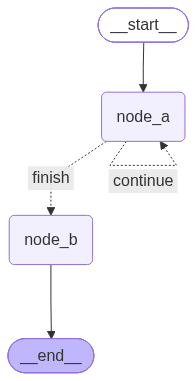

In [11]:
# 그래프 구성 : 노드 등록, 흐름 설정, 반복 + 종료 등의 조건 정의
# 그래프 : 실행 흐름을 관ㄹ- 실행 주체는 컴파일된 Graph 런타임이며 Graph 흐름에 따라 해당 함수들을 실행
def build_graph():
  graph = StateGraph(State)

  graph.add_node("node_a", node_a)
  graph.add_node("node_b", node_b)

  graph.set_entry_point("node_a")

  # 조건부 예제 설정 - 동적 라우팅 구현
  graph.add_conditional_edges(
      "node_a",     # 현재 노드
      route_next,   # 분기 조건 함수
      {
          "continue":"node_a",
          "finish":"node_b"
      }
  )

  graph.add_edge("node_b", END)   # node_b를 실행 후 그래프 종료
  return graph.compile()    # 구성(설계)가 완성된 그래프 반환

if __name__ == "__main__":
  graph = build_graph()

  # 상태 초기화
  state:State = {
      "counter":0,
      "alphabet":[],
      "processed":""
  }

  final_run = graph.invoke(state)
  print('final_run : ', final_run)
  print()
  print('counter : ', final_run['counter'])
  print('alphabet : ', final_run['alphabet'])
  print('processed : ', final_run['processed'])

  # 그래프 시각화
  try:
    from IPython.display import Image, display
    graph_obj = graph.get_graph()   # 내부 그래프 객체 얻기
    png_bytes = graph_obj.draw_mermaid_png()  # mermaid 기반 png 이미지 얻기
    display(Image(data=png_bytes))
  except Exception as e:
    print('Jupyter notebook 환경이 아니므로 그래프 출력 불가')
    print('에러 : ', e)
